# Data Exploration
This notebook loads and performs a preliminary exploration of the CSV datasets located in the `../dataset` directory.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from IPython.display import display

# Configure plotting style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:
# Locate all CSV files in the dataset directory
dataset_dir = "../dataset"
csv_pattern = os.path.join(dataset_dir, "*.csv")
csv_files = glob.glob(csv_pattern)

print(f"Found {len(csv_files)} CSV files in '{dataset_dir}':")
for f in csv_files:
    print(f"- {os.path.basename(f)}")

Found 4 CSV files in '../dataset':
- airlines.csv
- flights_live.csv
- airports.csv
- flights.csv


In [7]:
def explore_dataframe(df, name):
    """
    Performs basic exploration of a dataframe including:
    - Shape and data types
    - First few rows
    - Missing values
    - Descriptive statistics
    - Distribution plots for numeric columns
    """
    print(f"\n{'='*40}")
    print(f"Exploring: {name}")
    print(f"{'='*40}")
    
    # Basic Info
    print(f"\nShape: {df.shape}")
    print("\nData Types:")
    print(df.dtypes)
    
    # Preview
    print("\nFirst 5 rows:")
    display(df.head())
    
    # Missing Values
    print("\nMissing Values:")
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("No missing values found.")
        
    # Statistics
    print("\nDescriptive Statistics:")
    display(df.describe(include='all'))
    
    # Visualizations
    numeric_cols = df.select_dtypes(include=['number']).columns
    if len(numeric_cols) > 0:
        print(f"\nPlotting distributions for {len(numeric_cols)} numeric columns...")
        df[numeric_cols].hist(bins=20, figsize=(15, 2 * ((len(numeric_cols) // 3) + 1)), layout=(-1, 3))
        plt.suptitle(f"Distributions - {name}", y=1.02)
        plt.tight_layout()
        plt.show()
        
        if len(numeric_cols) > 1:
            plt.figure(figsize=(10, 8))
            sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
            plt.title(f"Correlation Matrix - {name}")
            plt.show()


Exploring: airlines.csv

Shape: (14, 2)

Data Types:
IATA_CODE    str
AIRLINE      str
dtype: object

First 5 rows:


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways



Missing Values:
No missing values found.

Descriptive Statistics:


,IATA_CODE,AIRLINE
count,14,14
unique,14,14
top,UA,United Air Lines Inc.
freq,1,1



Exploring: flights_live.csv

Shape: (5771, 22)

Data Types:
fr24_id           str
flight            str
callsign          str
lat               str
lon               str
track           int64
alt             int64
gspeed          int64
vspeed          int64
squawk          int64
timestamp         str
source            str
hex               str
type              str
reg               str
painted_as        str
operating_as      str
orig_iata         str
orig_icao         str
dest_iata         str
dest_icao         str
eta               str
dtype: object

First 5 rows:


,fr24_id,flight,callsign,lat,lon,track,alt,gspeed,vspeed,squawk,...,hex,type,reg,painted_as,operating_as,orig_iata,orig_icao,dest_iata,dest_icao,eta
0,3dfbb575,AA1349,AAL1349,3.281.462,-9.580.302,245,40000,346,0,565,...,ADC65E,B738,N987NN,AAL,AAL,JFK,KJFK,AUS,KAUS,2026-01-20T16:34:08Z
1,3dfbcb4e,DL2301,DAL2301,3.169.109,-8.577.339,138,39000,502,0,2637,...,A7824E,B753,N583NW,DAL,DAL,MSP,KMSP,TPA,KTPA,2026-01-20T16:44:48Z
2,3dfc602a,DL2582,DAL2582,3.593.753,-11.538.531,52,39000,436,0,2062,...,A0757F,BCS1,N129DU,DAL,DAL,BUR,KBUR,SLC,KSLC,2026-01-20T16:59:44Z
3,3dfbebeb,DL8851,DAL8851,3.786.596,-10.055.422,291,40000,368,0,7120,...,A8DEF1,B752,N6706Q,DAL,DAL,ATL,KATL,DEN,KDEN,2026-01-20T16:41:04Z
4,3dfc6248,UA1384,UAL1384,3.817.987,-10.132.871,278,38025,386,0,2526,...,AC4107,A319,N889UA,UAL,UAL,ICT,KICT,DEN,KDEN,2026-01-20T16:40:32Z



Missing Values:
painted_as       68
operating_as     68
dest_iata         6
dest_icao         6
eta             250
dtype: int64

Descriptive Statistics:


,fr24_id,flight,callsign,lat,lon,track,alt,gspeed,vspeed,squawk,...,hex,type,reg,painted_as,operating_as,orig_iata,orig_icao,dest_iata,dest_icao,eta
count,5771,5771,5771,5771,5771,5771.000000,5771.000000,5771.000000,5771.000000,5771.000000,...,5771,5771,5771,5703,5703,5771,5771,5765,5765,5521
unique,163,150,150,5453,5460,NaN,NaN,NaN,NaN,NaN,...,151,24,151,9,9,68,68,45,45,1256
top,3dfb1035,DL274,DAL274,4.221.032,-8.335.699,NaN,NaN,NaN,NaN,NaN,...,A65800,B738,N508DN,DAL,DAL,AMS,EHAM,IAH,KIAH,2026-01-20T19:01:20Z
freq,94,168,168,53,57,NaN,NaN,NaN,NaN,NaN,...,94,880,94,1529,1529,430,430,462,462,77
mean,NaN,NaN,NaN,NaN,NaN,188.459366,28587.454514,369.459019,-119.627101,3311.591059,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,86.587259,14799.180789,169.091334,702.425326,2191.319005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,-4032.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,118.000000,19712.500000,326.000000,0.000000,1523.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,206.000000,36975.000000,408.000000,0.000000,3031.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,255.000000,38887.500000,496.000000,0.000000,4614.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Plotting distributions for 5 numeric columns...


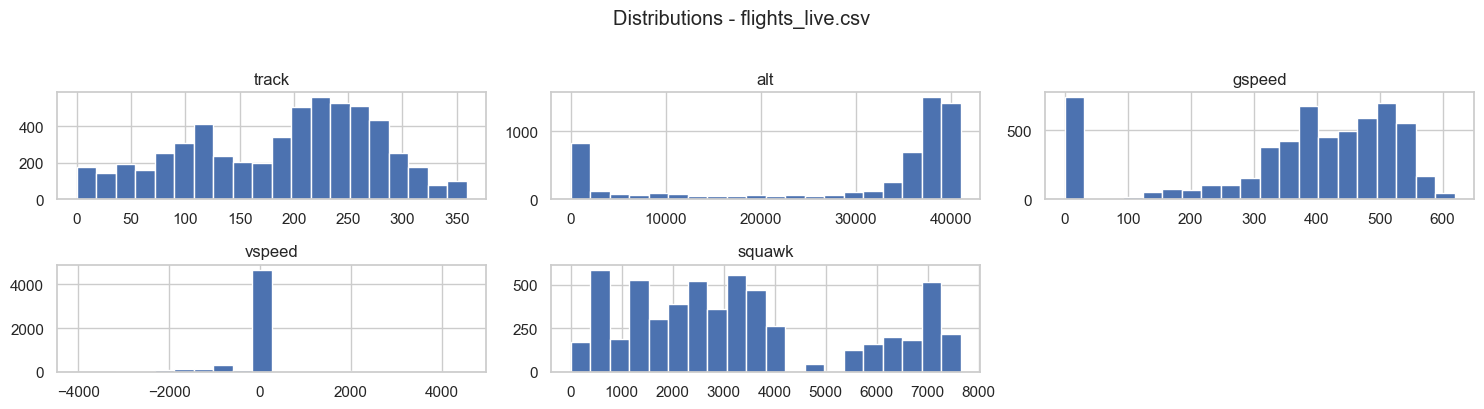

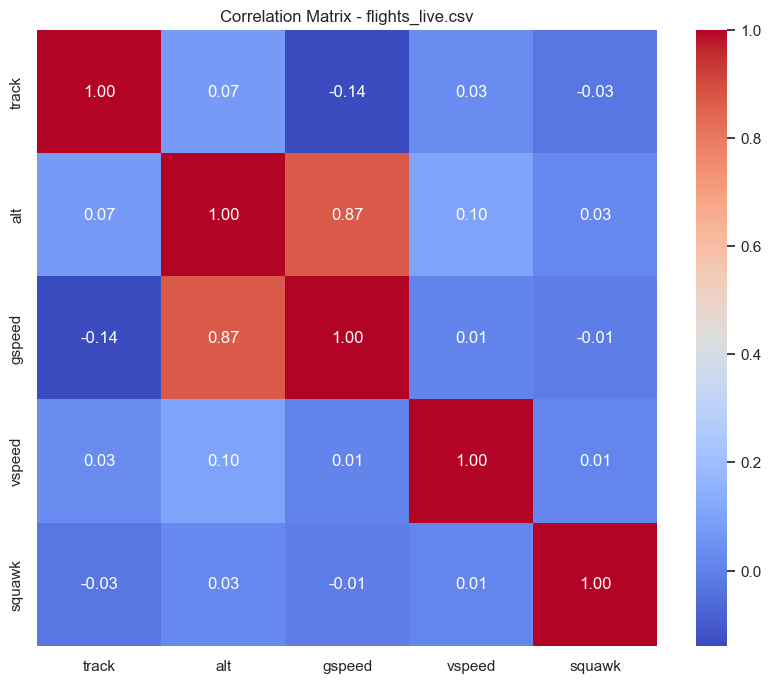


Exploring: airports.csv

Shape: (322, 7)

Data Types:
IATA_CODE        str
AIRPORT          str
CITY             str
STATE            str
COUNTRY          str
LATITUDE     float64
LONGITUDE    float64
dtype: object

First 5 rows:


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447



Missing Values:
LATITUDE     3
LONGITUDE    3
dtype: int64

Descriptive Statistics:


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
count,322,322,322,322,322,319.000000,319.000000
unique,322,322,308,54,1,NaN,NaN
top,ABE,Lehigh Valley International Airport,Albany,TX,USA,NaN,NaN
freq,1,1,2,24,322,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,38.981244,-98.378964
std,NaN,NaN,NaN,NaN,NaN,8.616736,21.523492
min,NaN,NaN,NaN,NaN,NaN,13.483450,-176.646030
25%,NaN,NaN,NaN,NaN,NaN,33.652040,-110.839385
50%,NaN,NaN,NaN,NaN,NaN,39.297610,-93.403070
75%,NaN,NaN,NaN,NaN,NaN,43.154675,-82.722995



Plotting distributions for 2 numeric columns...


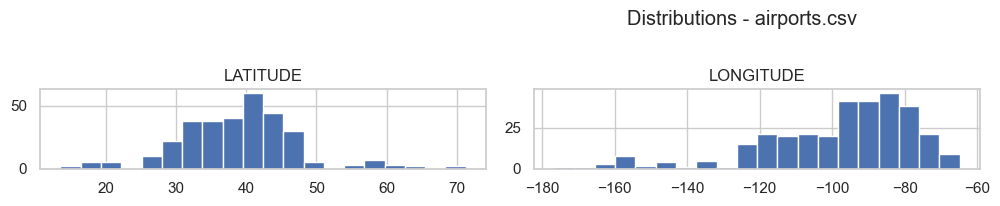

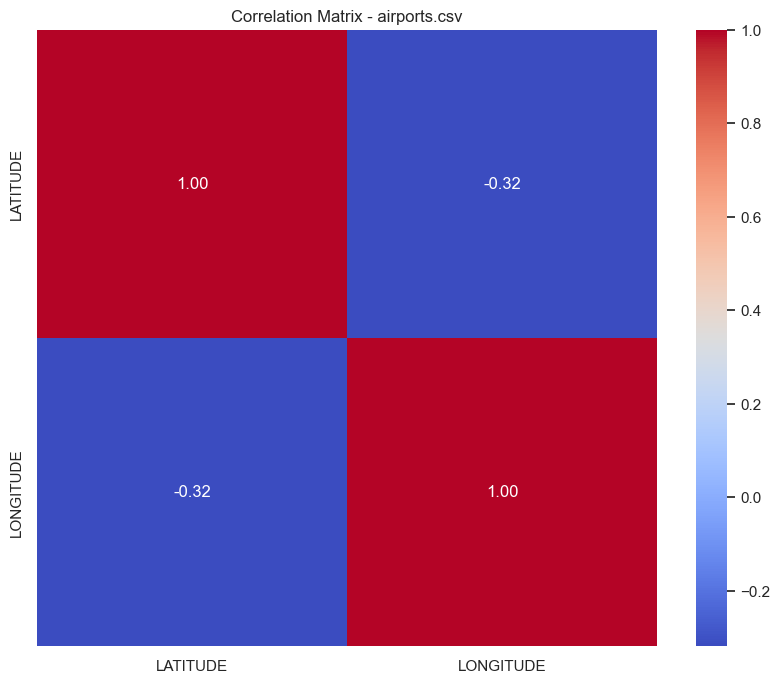

/var/folders/zv/rs48kt_94v14k0mtc2p3v5c80000gn/T/ipykernel_52977/788122022.py:6: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)



Exploring: flights.csv

Shape: (5819079, 31)

Data Types:
YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                    str
FLIGHT_NUMBER            int64
TAIL_NUMBER                str
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON        str
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DEL

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN



Missing Values:
TAIL_NUMBER              14721
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
WHEELS_ON                92513
TAXI_IN                  92513
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

Descriptive Statistics:


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5819079,5.819079e+06,5804358,5819079,5819079,5.819079e+06,...,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,89884,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
unique,NaN,NaN,NaN,NaN,14,NaN,4897,930,930,NaN,...,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,WN,NaN,N480HA,ATL,ATL,NaN,...,NaN,NaN,NaN,NaN,B,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,1261855,NaN,3768,346836,346904,NaN,...,NaN,NaN,NaN,NaN,48851,NaN,NaN,NaN,NaN,NaN
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,NaN,2.173093e+03,NaN,NaN,NaN,1.329602e+03,...,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,NaN,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,NaN,1.757064e+03,NaN,NaN,NaN,4.837518e+02,...,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,NaN,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,NaN,1.000000e+00,NaN,NaN,NaN,1.000000e+00,...,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,NaN,7.300000e+02,NaN,NaN,NaN,9.170000e+02,...,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,NaN,1.690000e+03,NaN,NaN,NaN,1.325000e+03,...,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,NaN,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,NaN,3.230000e+03,NaN,NaN,NaN,1.730000e+03,...,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,NaN,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00



Plotting distributions for 26 numeric columns...


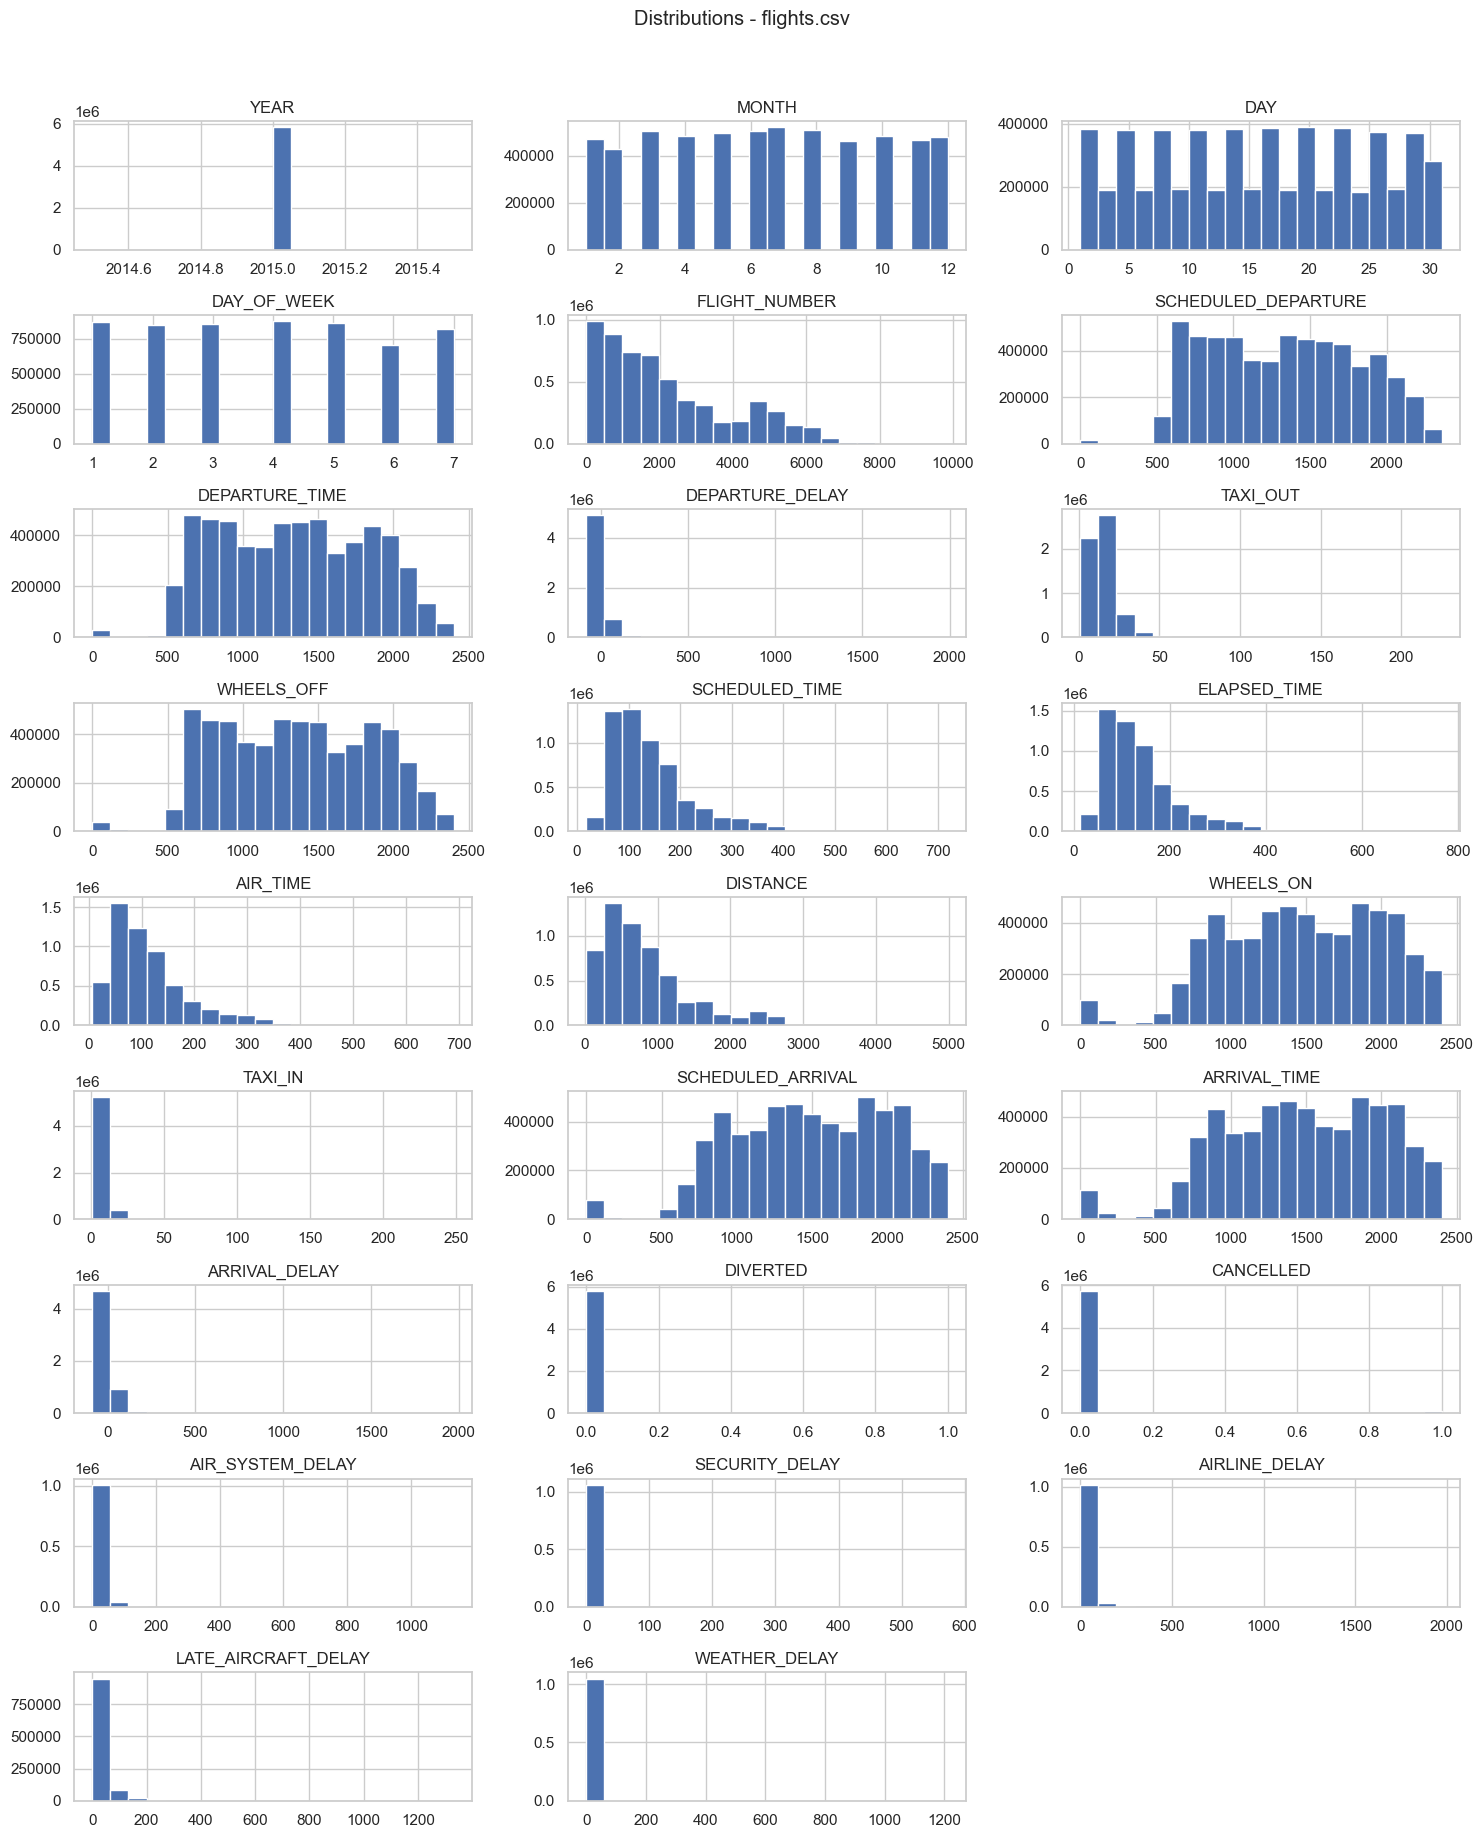

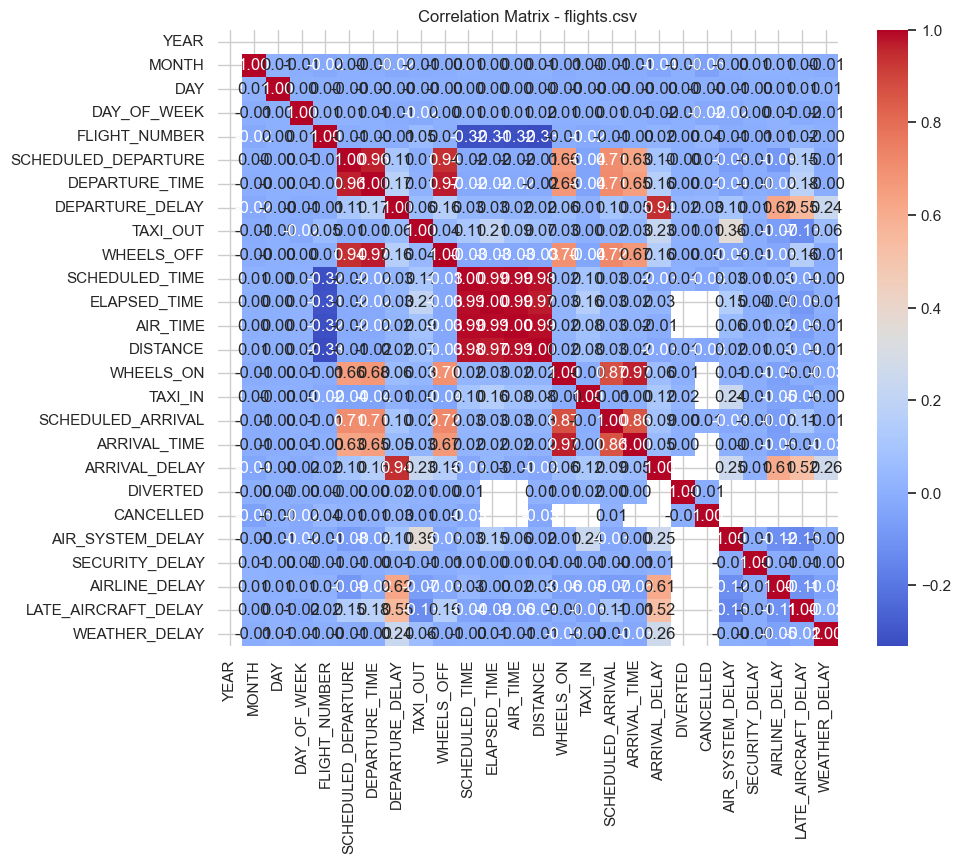

In [8]:
# Iterate through files and explore
for file_path in csv_files:
    try:
        filename = os.path.basename(file_path)
        # Read the CSV
        df = pd.read_csv(file_path)
        explore_dataframe(df, filename)
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")